In [53]:
# Experiment 1

In [2]:
import matplotlib.pyplot as plt
import re

# File paths
file_paths = ['results/list_acc_new.txt', 'results_new/acc/list_acc_9_11.txt']

# Initialize a variable to store the combined content of both files
combined_data = ""

# Loop through the files and read the content, then concatenate
for file_path in file_paths:
    try:
        with open(file_path, 'r') as file:
            data = file.read()
            # Concatenate the content of the current file to combined_data
            combined_data += data + "\n"  # Add a newline to separate file contents
    except FileNotFoundError:
        print(f"File {file_path} not found!")


data = combined_data
# # Read the file content
# file_path = 'results/list_acc_new.txt'
# file_path = 'results_new/acc/list_acc_9_11.txt'
# with open(file_path, 'r') as file:
#     data = file.read()

# Extract model, dataset, language, and accuracy list information
pattern = r'Model:\s*(.*?),\s*Dataset:\s*(.*?),\s*Language:\s*(.*?),\s*Accuracy List:\s*\[(.*?)\]'
matches = re.findall(pattern, data)

# Create a dictionary to store language and accuracy information for each model-dataset combination
results = {}

for model, dataset, language, acc_list in matches:
    if (model, dataset) not in results:
        results[(model, dataset)] = {}
    results[(model, dataset)][language] = list(map(float, acc_list.split(', ')))

# Define the desired language order
language_order = ['English', 'German', 'French', 'Chinese', 'Spanish', 'Russian', 'Indonesian', 
                  'Oriya', 'Hindi', 'Burmese', 'Hawaiian', 'Kannada', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen']

# Define the desired model order (Qwen-1.8B after Qwen-0.5B, and ensure correct Gemma-2B naming)
model_order = ['Qwen-0.5B', 'Qwen-1.8B', 'gemma-2b', 'Qwen-7B', 'gemma-7b']
model_order = ['Qwen-7B', 'gemma-7b']

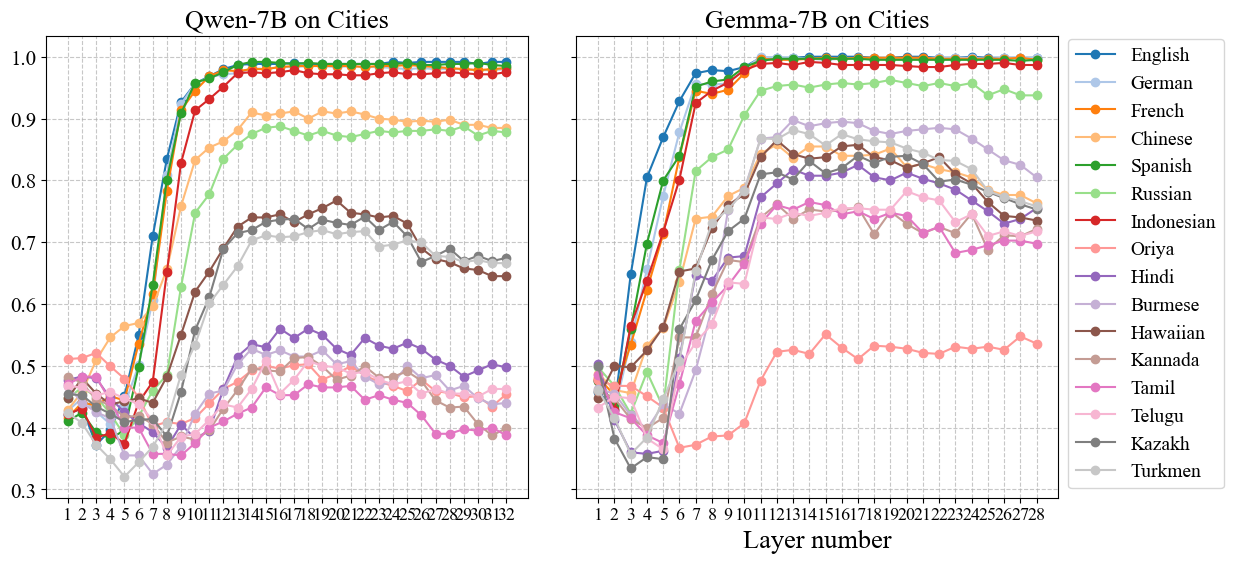

In [15]:
cmap = plt.get_cmap('tab20')  # 'tab20' colormap has 20 distinct colors

# Set the global font
plt.rcParams['font.family'] = 'Times New Roman'

datasets_to_plot = {'cities', 'opinion'}
for dataset in datasets_to_plot:
    # Create a figure with two subplots arranged horizontally (1 row, 2 columns)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)  # Adjust the figure size for horizontal layout
    
    # Store handles and labels for the combined legend
    handles, labels = [], []
    
    # Filter models for the dataset and apply the desired order
    models_for_dataset = [model for model in model_order if (model, dataset) in results]
    
    for i, model in enumerate(models_for_dataset[:2]):  # Limiting to 2 plots per dataset
        ax = axs[i]
        languages_data = results[(model, dataset)]
        
        # Sort the languages based on the predefined order
        for j, language in enumerate(language_order[:16]):  # Ensure you only plot 16 distinct languages
            if language in languages_data:
                line, = ax.plot(languages_data[language], marker='o', label=language, color=cmap(j))  # Assign colors from tab20 colormap
                handles.append(line)  # Collect handles for the legend
                labels.append(language)  # Collect labels for the legend
        
        if model == 'gemma-2b':
            model = 'Gemma-2B'
        if model == 'gemma-7b':
            model = 'Gemma-7B'
        if dataset == 'cities':
            ax.set_title(f'{model} on Cities', fontsize=19)
        else:
            ax.set_title(f'{model} on {dataset}', fontsize=16)
        
        # Ensure all subplots show x-ticks and x-tick labels
        ax.set_xticks(range(len(next(iter(languages_data.values())))))
        ax.set_xticklabels(range(1, len(next(iter(languages_data.values()))) + 1), fontsize=13)
        ax.tick_params(axis='y', labelsize=15)
        ax.grid(True, linestyle='--', alpha=0.7)

    # Set the x-axis label for all plots
    axs[1].set_xlabel('Layer number', fontsize=19)

    # Adjust the spacing between subplots
    plt.subplots_adjust(wspace=0.1, right=0.8)  # Increase right spacing to accommodate legend

    # Add a single shared legend for both plots
    fig.legend(handles=handles[:16], labels=labels[:16], loc='center left', bbox_to_anchor=(0.8, 0.5), fontsize=14)  # One shared legend

    # Save the combined figure as a PDF
    pdf_filename = f'results/figure/{dataset}/{dataset}_experiment1_v4.jpg'.replace(' ', '_')
    plt.savefig(pdf_filename, format='jpg', bbox_inches='tight')

    plt.show()
    break


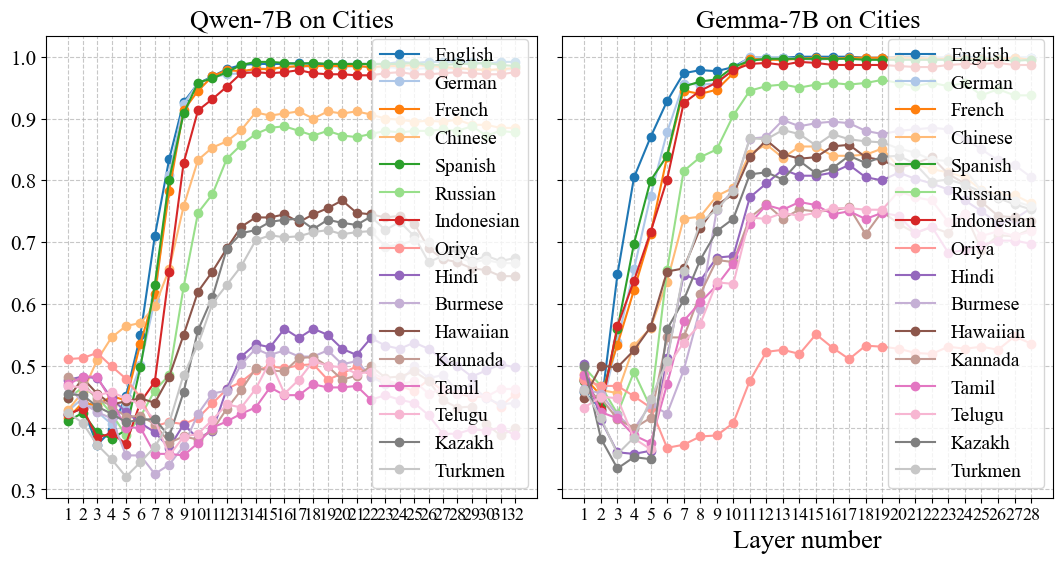

In [6]:
# Define a colormap for 16 distinct colors using tab20
cmap = plt.get_cmap('tab20')  # 'tab20' colormap has 20 distinct colors

# Set the global font
plt.rcParams['font.family'] = 'Times New Roman'

datasets_to_plot = {'cities', 'opinion'}
for dataset in datasets_to_plot:
    # Create a figure with three subplots arranged horizontally (1 row, 3 columns)
    fig, axs = plt.subplots(1, 5, figsize=(19, 6), sharey=True)  # Adjust the figure size for horizontal layout
    
    # Filter models for the dataset and apply the desired order
    models_for_dataset = [model for model in model_order if (model, dataset) in results]
    
    for i, model in enumerate(models_for_dataset[:5]):  # Limiting to 3 plots per dataset
        ax = axs[i]
        languages_data = results[(model, dataset)]
        
        # Sort the languages based on the predefined order
        for j, language in enumerate(language_order[:16]):  # Ensure you only plot 16 distinct languages
            if language in languages_data:
                ax.plot(languages_data[language], marker='o', label=language, color=cmap(j))  # Assign colors from tab20 colormap
        
        if model == 'gemma-2b':
            model = 'Gemma-2B'
        if model == 'gemma-7b':
            model = 'Gemma-7B'
        if dataset == 'cities':
            ax.set_title(f'{model} on Cities', fontsize=19)
        else:
            ax.set_title(f'{model} on {dataset}', fontsize=16)
        
        # Ensure all subplots show x-ticks and x-tick labels
        ax.set_xticks(range(len(next(iter(languages_data.values())))))
        ax.set_xticklabels(range(1, len(next(iter(languages_data.values()))) + 1), fontsize=13)
        ax.tick_params(axis='y', labelsize=15)
        ax.legend(loc='lower right', fontsize=14)  # Increase the legend font size
        ax.grid(True, linestyle='--', alpha=0.7)

    # Set the x-axis label for all plots
    axs[1].set_xlabel('Layer number', fontsize=19)

    # Adjust the spacing between subplots
    plt.subplots_adjust(wspace=0.05)

    # Save the combined figure as a PDF
    pdf_filename = f'results/figure/{dataset}/{dataset}_experiment1_v4.pdf'.replace(' ', '_')
#     plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

    plt.show()
    break

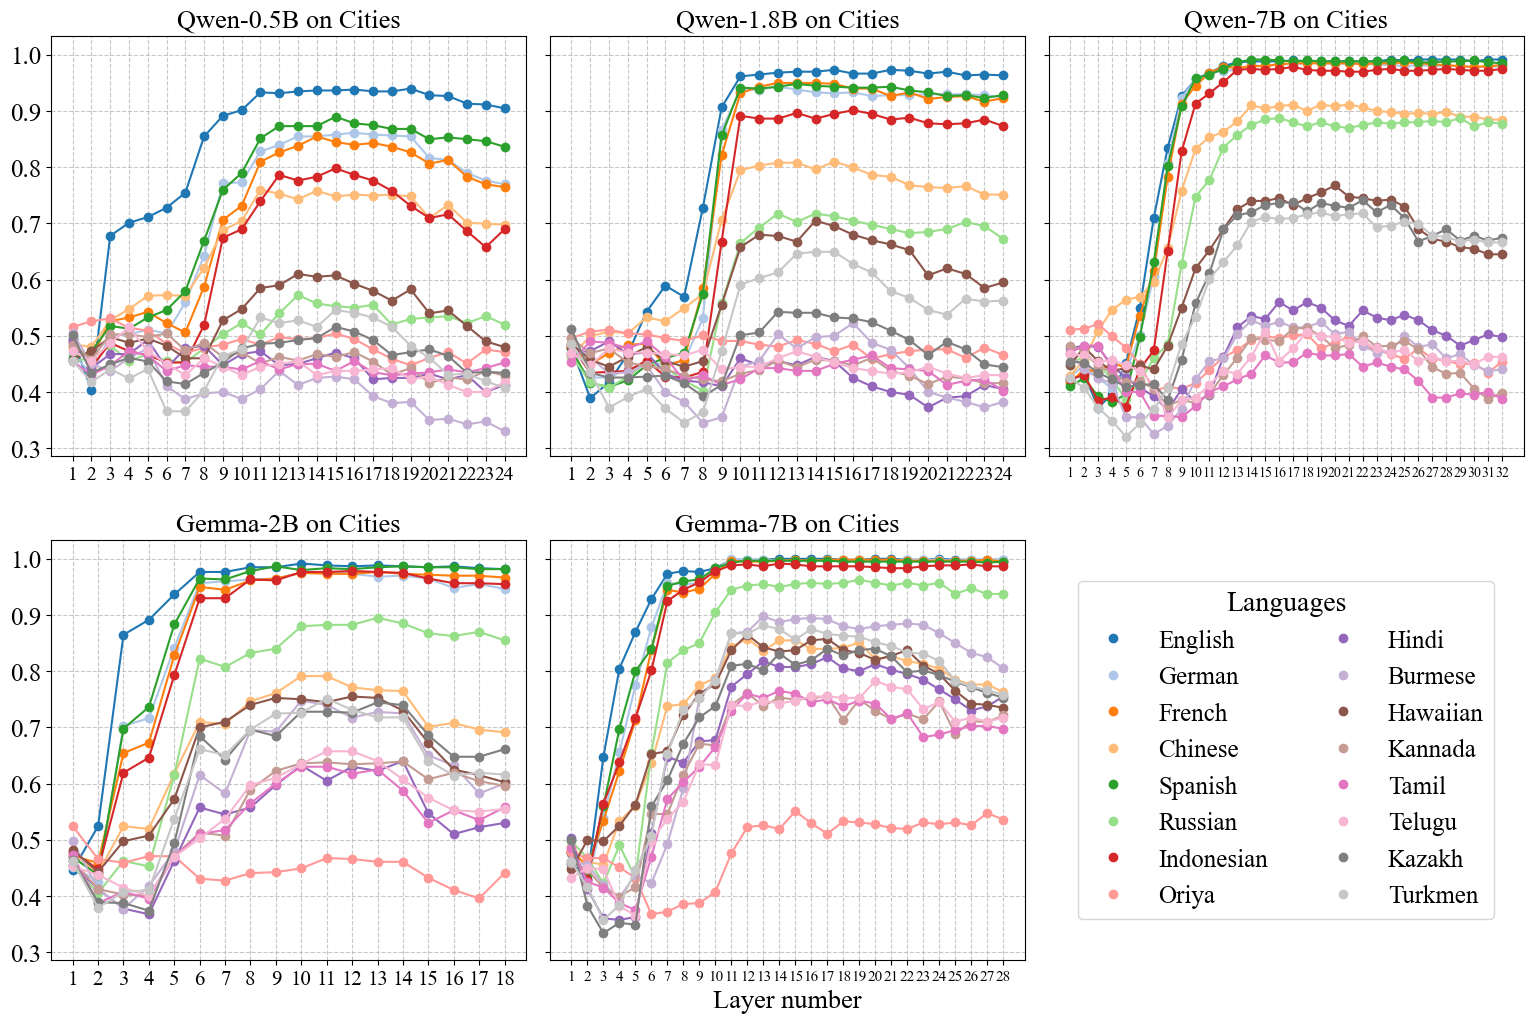

In [1]:
import matplotlib.pyplot as plt
import re

# File paths
file_paths = ['results/list_acc_new.txt', 'results_new/acc/list_acc_9_11.txt']

# Initialize a variable to store the combined content of both files
combined_data = ""

# Loop through the files and read the content, then concatenate
for file_path in file_paths:
    try:
        with open(file_path, 'r') as file:
            data = file.read()
            # Concatenate the content of the current file to combined_data
            combined_data += data + "\n"  # Add a newline to separate file contents
    except FileNotFoundError:
        print(f"File {file_path} not found!")

data = combined_data

# Extract model, dataset, language, and accuracy list information
pattern = r'Model:\s*(.*?),\s*Dataset:\s*(.*?),\s*Language:\s*(.*?),\s*Accuracy List:\s*\[(.*?)\]'
matches = re.findall(pattern, data)

# Create a dictionary to store language and accuracy information for each model-dataset combination
results = {}

for model, dataset, language, acc_list in matches:
    if (model, dataset) not in results:
        results[(model, dataset)] = {}
    results[(model, dataset)][language] = list(map(float, acc_list.split(', ')))

# Define the language groups
high_resource_languages = ['English', 'German', 'French', 'Chinese', 'Spanish', 'Russian', 'Indonesian']
low_resource_languages = ['Oriya', 'Hindi', 'Burmese', 'Hawaiian', 'Kannada', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen']

# Define the desired model order
model_order = ['Qwen-0.5B', 'Qwen-1.8B', 'Qwen-7B', 'gemma-2b', 'gemma-7b']
# Define a colormap for 16 distinct colors using tab20
cmap = plt.get_cmap('tab20')  # 'tab20' colormap has 20 distinct colors

# Set the global font
plt.rcParams['font.family'] = 'Times New Roman'

datasets_to_plot = {'cities'}
for dataset in datasets_to_plot:
    # Create a figure with two rows and three columns (2x3 grid)
    fig, axs = plt.subplots(2, 3, figsize=(19, 12), sharey=True)
    
    # Filter models for the dataset and apply the desired order
    models_for_dataset = [model for model in model_order if (model, dataset) in results]
    
    # Plot for the first three models in the first row
    for i, model in enumerate(models_for_dataset[:3]):
        ax = axs[0, i]  # First row, columns 0 to 2
        languages_data = results[(model, dataset)]
        
        # Sort the languages based on the predefined order
        for j, language in enumerate(high_resource_languages + low_resource_languages):  # Plot high and low resource languages
            if language in languages_data:
                ax.plot(languages_data[language], marker='o', label=language, color=cmap(j))  # Assign colors from tab20 colormap
        
        if model == 'gemma-2b':
            model = 'Gemma-2B'
        if model == 'gemma-7b':
            model = 'Gemma-7B'
        if dataset == 'cities':
            ax.set_title(f'{model} on Cities', fontsize=19)
        else:
            ax.set_title(f'{model} on {dataset}', fontsize=16)
        
        # Ensure all subplots show x-ticks and x-tick labels
        ax.set_xticks(range(len(next(iter(languages_data.values())))))
        if model == 'Qwen-7B':
            ax.set_xticklabels(range(1, len(next(iter(languages_data.values()))) + 1), fontsize=10)
        else:
            ax.set_xticklabels(range(1, len(next(iter(languages_data.values()))) + 1), fontsize=14)
        ax.tick_params(axis='y', labelsize=18)
        ax.grid(True, linestyle='--', alpha=0.7)

    # Plot for the next two models in the second row
    for i, model in enumerate(models_for_dataset[3:]):
        ax = axs[1, i]  # Second row, columns 0 and 1
        languages_data = results[(model, dataset)]
        
        # Sort the languages based on the predefined order
        for j, language in enumerate(high_resource_languages + low_resource_languages):  # Plot high and low resource languages
            if language in languages_data:
                ax.plot(languages_data[language], marker='o', label=language, color=cmap(j))  # Assign colors from tab20 colormap
        
        if model == 'gemma-2b':
            model = 'Gemma-2B'
        if model == 'gemma-7b':
            model = 'Gemma-7B'
        if dataset == 'cities':
            ax.set_title(f'{model} on Cities', fontsize=19)
        else:
            ax.set_title(f'{model} on {dataset}', fontsize=16)
        
        # Ensure all subplots show x-ticks and x-tick labels
        ax.set_xticks(range(len(next(iter(languages_data.values())))))
        if model == 'Gemma-7B':
            ax.set_xticklabels(range(1, len(next(iter(languages_data.values()))) + 1), fontsize=11)
        else:
            ax.set_xticklabels(range(1, len(next(iter(languages_data.values()))) + 1), fontsize=15)
        ax.tick_params(axis='y', labelsize=18)
        ax.grid(True, linestyle='--', alpha=0.7)

#     # Place the split legend in the last subplot (second row, third column)
#     axs[1, 2].axis('off')  # Turn off the axes for this subplot
    
#     # Create handles for high-resource and low-resource languages
#     handles_high = [plt.Line2D([0], [0], color=cmap(j), marker='o', linestyle='') for j in range(len(high_resource_languages))]
#     handles_low = [plt.Line2D([0], [0], color=cmap(j + len(high_resource_languages)), marker='o', linestyle='') for j in range(len(low_resource_languages))]
    
#     # Display the high-resource languages legend at the top of the empty subplot
#     axs[1, 2].legend(handles_high, high_resource_languages, title="High-resource languages", loc='center left', fontsize=12)
    
#     # Display the low-resource languages legend at the bottom of the empty subplot
#     axs[1, 2].legend(handles_low, low_resource_languages, title="Low-resource languages", loc='center right', fontsize=12)
    
#     # Set the x-axis label for all plots
#     axs[1, 1].set_xlabel('Layer number', fontsize=19)

#     # Adjust the spacing between subplots
#     plt.subplots_adjust(wspace=0.2, hspace=0.3)

#     # Show the figure
#     plt.show()
    
    axs[1, 2].axis('off')  # Turn off the axes for this subplot

    # Create handles for both high-resource and low-resource languages
    handles_high = [plt.Line2D([0], [0], color=cmap(j), marker='o', linestyle='') for j in range(len(high_resource_languages))]
    handles_low = [plt.Line2D([0], [0], color=cmap(j + len(high_resource_languages)), marker='o', linestyle='') for j in range(len(low_resource_languages))]

    # Combine handles and labels for both high-resource and low-resource languages
    combined_handles = handles_high + handles_low
    combined_labels = high_resource_languages + low_resource_languages

    # Display the combined legend in the empty subplot with two columns (one for high-resource, one for low-resource languages)
    axs[1, 2].legend(combined_handles, combined_labels, title="Languages", loc='center', title_fontsize=20, fontsize=18, ncol=2, bbox_to_anchor=(0.5, 0.5))

    # Set the x-axis label for all plots
    axs[1, 1].set_xlabel('Layer number', fontsize=19)

    # Adjust the spacing between subplots
    plt.subplots_adjust(wspace=0.05, hspace=0.2)
    
    # Save the combined figure as a PDF
    pdf_filename = f'results/figure/{dataset}/{dataset}_experiment1_5fig.jpg'.replace(' ', '_')
    plt.savefig(pdf_filename, format='jpg', bbox_inches='tight')

    # Show the figure
    plt.show()


In [ ]:
# Experiment 1 Appendix

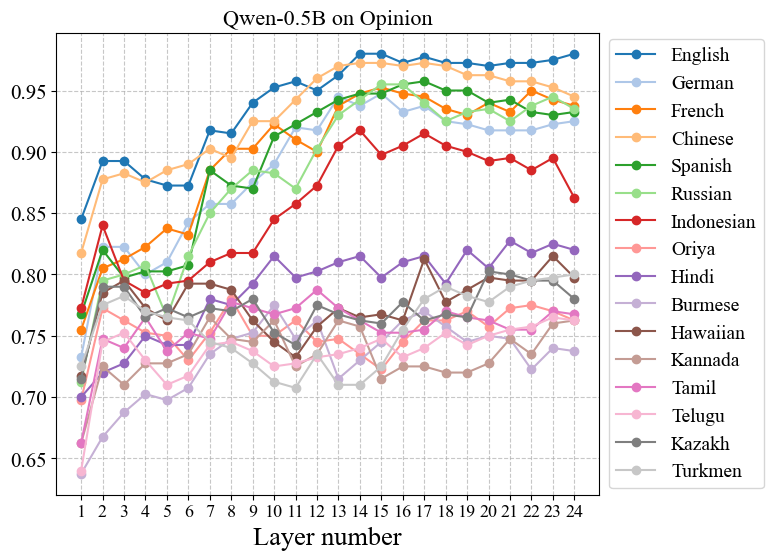

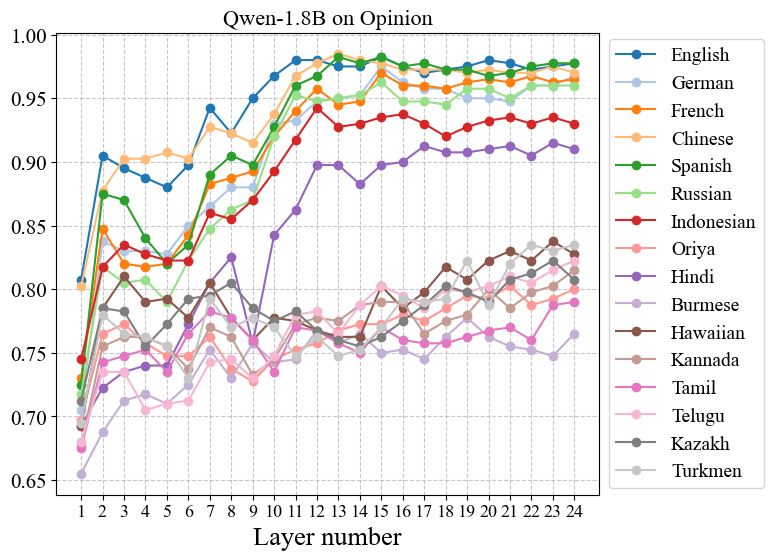

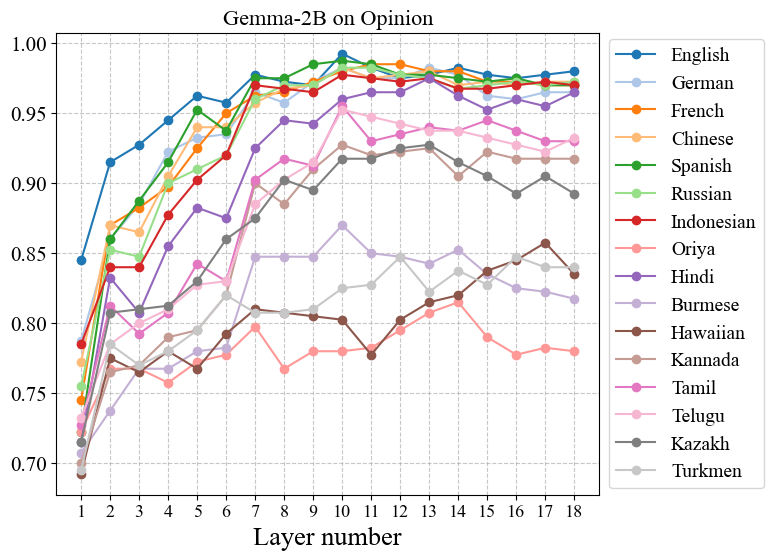

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import re

# Read the file content
file_path = 'results/list_acc_new.txt'
# file_path = 'results_new/acc/list_acc_9_11.txt'
with open(file_path, 'r') as file:
    data = file.read()

# Extract model, dataset, language, and accuracy list information
pattern = r'Model:\s*(.*?),\s*Dataset:\s*(.*?),\s*Language:\s*(.*?),\s*Accuracy List:\s*\[(.*?)\]'
matches = re.findall(pattern, data)

# Create a dictionary to store language and accuracy information for each model-dataset combination
results = {}

for model, dataset, language, acc_list in matches:
    if (model, dataset) not in results:
        results[(model, dataset)] = {}
    results[(model, dataset)][language] = list(map(float, acc_list.split(', ')))

# Define the desired language order
language_order = ['English', 'German', 'French', 'Chinese', 'Spanish', 'Russian', 'Indonesian', 
                  'Oriya', 'Hindi', 'Burmese', 'Hawaiian', 'Kannada', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen']

# Define the desired model order (Qwen-1.8B after Qwen-0.5B, and ensure correct Gemma-2B naming)
model_order = ['Qwen-0.5B', 'Qwen-1.8B', 'gemma-2b']
# model_order = ['Qwen-7B', 'gemma-7b']

# Define a colormap for 16 distinct colors using tab20
cmap = plt.get_cmap('tab20')  # 'tab20' colormap has 20 distinct colors

# Set the global font
plt.rcParams['font.family'] = 'Times New Roman'

datasets_to_plot = {'opinion'}
for dataset in datasets_to_plot:
    
    # Filter models for the dataset and apply the desired order
    models_for_dataset = [model for model in model_order if (model, dataset) in results]
    
    for i, model in enumerate(models_for_dataset[:3]):  # Limiting to 3 plots per dataset
        fig, ax = plt.subplots(figsize=(7, 6))  # Create a new figure for each plot
        languages_data = results[(model, dataset)]
        
        # Sort the languages based on the predefined order
        for j, language in enumerate(language_order[:16]):  # Ensure you only plot 16 distinct languages
            if language in languages_data:
                ax.plot(languages_data[language], marker='o', label=language, color=cmap(j))  # Assign colors from tab20 colormap
        
        if model == 'gemma-2b':
            model = 'Gemma-2B'
        if model == 'gemma-7b':
            model = 'Gemma-7B'
        
        ax.set_title(f'{model} on Opinion', fontsize=16)
        
        # Ensure the plot shows x-ticks and x-tick labels
        ax.set_xticks(range(len(next(iter(languages_data.values())))))
        ax.set_xticklabels(range(1, len(next(iter(languages_data.values()))) + 1), fontsize=13)
        ax.tick_params(axis='y', labelsize=15)
#         ax.legend(loc='lower right', fontsize=14)  # Increase the legend font size
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)  # 将 legend 移到右侧外面
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Set the x-axis label
        ax.set_xlabel('Layer number', fontsize=19)

        # Save each figure as a separate PDF
        pdf_filename = f'results/figure/{dataset}/{model}_{dataset}_experiment1_app_v2.pdf'.replace(' ', '_')
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

        # Show each plot
        plt.show()

In [1]:
import pandas as pd
from tabulate import tabulate

def create_multilingual_prompt_table():
    data = {
        'Language': [
            'English', 'Chinese', 'French', 'German', 'Indonesian', 'Spanish',
            'Kannada', 'Kazakh', 'Oriya', 'Turkmen', 'Russian', 'Hindi',
            'Burmese', 'Tagalog', 'Hawaiian', 'Tamil', 'Telugu', 'Turkish'
        ],
        'Prompt': [
            'Judge the statement is Positive or Negative.',
            '判断该陈述是正面的还是负面的。',
            "Jugez si l'énoncé est positif ou négatif.",
            'Beurteilen Sie, ob die Aussage positiv oder negativ ist.',
            'Tentukan apakah pernyataan tersebut positif atau negatif.',
            'Juzgue si la afirmación es positiva o negativa.',
            'ಹೇಳಿಕೆಯನ್ನು ಸಕಾರಾತ್ಮಕ ಅಥವಾ ಋಣಾತ್ಮಕ ಎಂದು ತೀರ್ಮಾನಿಸಿ.',
            'Мәлімдеменің оң немесе теріс екенін анықтаңыз.',
            'ବିବେଚନା କରନ୍ତୁ ଯେ ବକ୍ତବ୍ୟଟି ସକାରାତ୍ମକ କି ନକାରାତ୍ମକ।',
            'Beýannamanyň oňyn ýa-da otrisatelidigini kesgitläň.',
            'Оцените, является ли утверждение положительным или отрицательным.',
            'निर्णय करें कि कथन सकारात्मक है या नकारात्मक।',
            'ထောက်ထားချက်သည်အနုမြူရောအနုတ်မြူရောဖြစ်သည်။',
            'Husgahan kung ang pahayag ay positibo o negatibo.',
            'E hoʻopaʻapaʻa inā he maikaʻi a i ʻole he maikaʻi ʻole ka ʻōlelo.',
            'வாக்குமூலம் நேர்மையானதா அல்லது எதிர்மையானதா என்பதை மதிப்பீடு செய்யவும்.',
            'వాఖ్యానికి సానుకూలం లేదా ప్రతికూలం అని తీర్పు ఇవ్వండి.',
            'İfadenin olumlu veya olumsuz olduğunu değerlendirin.'
        ]
    }

    df = pd.DataFrame(data)
    
    # Create a table using tabulate
    table = tabulate(df, headers='keys', tablefmt='pipe', showindex=False)
    
    return table

if __name__ == "__main__":
    multilingual_table = create_multilingual_prompt_table()
    print(multilingual_table)

| Language   | Prompt                                                            |
|:-----------|:------------------------------------------------------------------|
| English    | Judge the statement is Positive or Negative.                      |
| Chinese    | 判断该陈述是正面的还是负面的。                                    |
| French     | Jugez si l'énoncé est positif ou négatif.                         |
| German     | Beurteilen Sie, ob die Aussage positiv oder negativ ist.          |
| Indonesian | Tentukan apakah pernyataan tersebut positif atau negatif.         |
| Spanish    | Juzgue si la afirmación es positiva o negativa.                   |
| Kannada    | ಹೇಳಿಕೆಯನ್ನು ಸಕಾರಾತ್ಮಕ ಅಥವಾ ಋಣಾತ್ಮಕ ಎಂದು ತೀರ್ಮಾನಿಸಿ.                                 |
| Kazakh     | Мәлімдеменің оң немесе теріс екенін анықтаңыз.                    |
| Oriya      | ବିବେଚନା କରନ୍ତୁ ଯେ ବକ୍ତବ୍ୟଟି ସକାରାତ୍ମକ କି ନକାରାତ୍ମକ।                               |
| Turkmen    | Beýannamanyň oňyn ýa-da otrisatelidigini kesgitläň.  

In [7]:
import pandas as pd
from tabulate import tabulate
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter, landscape
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.pdfbase.pdfmetrics import registerFontFamily
from reportlab.lib.fonts import addMapping

def create_multilingual_prompt_table():
    data = {
        'Language': [
            'English', 'Chinese', 'French', 'German', 'Indonesian', 'Spanish',
            'Kannada', 'Kazakh', 'Oriya', 'Turkmen', 'Russian', 'Hindi',
            'Burmese', 'Tagalog', 'Hawaiian', 'Tamil', 'Telugu', 'Turkish'
        ],
        'Prompt': [
            'Judge the statement is Positive or Negative.',
            '判断该陈述是正面的还是负面的。',
            "Jugez si l'énoncé est positif ou négatif.",
            'Beurteilen Sie, ob die Aussage positiv oder negativ ist.',
            'Tentukan apakah pernyataan tersebut positif atau negatif.',
            'Juzgue si la afirmación es positiva o negativa.',
            'ಹೇಳಿಕೆಯನ್ನು ಸಕಾರಾತ್ಮಕ ಅಥವಾ ಋಣಾತ್ಮಕ ಎಂದು ತೀರ್ಮಾನಿಸಿ.',
            'Мәлімдеменің оң немесе теріс екенін анықтаңыз.',
            'ବିବେଚନା କରନ୍ତୁ ଯେ ବକ୍ତବ୍ୟଟି ସକାରାତ୍ମକ କି ନକାରାତ୍ମକ।',
            'Beýannamanyň oňyn ýa-da otrisatelidigini kesgitläň.',
            'Оцените, является ли утверждение положительным или отрицательным.',
            'निर्णय करें कि कथन सकारात्मक है या नकारात्मक।',
            'ထောက်ထားချက်သည်အနုမြူရောအနုတ်မြူရောဖြစ်သည်။',
            'Husgahan kung ang pahayag ay positibo o negatibo.',
            'E hoʻopaʻapaʻa inā he maikaʻi a i ʻole he maikaʻi ʻole ka ʻōlelo.',
            'வாக்குமூலம் நேர்மையானதா அல்லது எதிர்மையானதா என்பதை மதிப்பீடு செய்யவும்.',
            'వాఖ్యానికి సానుకూలం లేదా ప్రతికూలం అని తీర్పు ఇవ్వండి.',
            'İfadenin olumlu veya olumsuz olduğunu değerlendirin.'
        ]
    }

    df = pd.DataFrame(data)
    return df

def save_table_as_pdf(df, output_filename):
    # Create the PDF document
    doc = SimpleDocTemplate(output_filename, pagesize=landscape(letter))

    # Convert DataFrame to a list of lists
    data = [df.columns.tolist()] + df.values.tolist()

    # Create the table
    table = Table(data)

    # Get the default style sheet
    styles = getSampleStyleSheet()
    
    # Add style to the table
    style = TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, -1), 'Helvetica-Bold'),  # Using a standard font
        ('FONTSIZE', (0, 0), (-1, -1), 8),
        ('BOTTOMPADDING', (0, 0), (-1, -1), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ])
    table.setStyle(style)

    # Build the PDF
    elements = [table]
    doc.build(elements)

if __name__ == "__main__":
    df = create_multilingual_prompt_table()
    
    # Print the table to console
    print(tabulate(df, headers='keys', tablefmt='pipe', showindex=False))
    
    # Save the table as PDF
    save_table_as_pdf(df, 'multilingual_prompts.pdf')
    print("\nTable has been saved as 'multilingual_prompts.pdf'")

| Language   | Prompt                                                            |
|:-----------|:------------------------------------------------------------------|
| English    | Judge the statement is Positive or Negative.                      |
| Chinese    | 判断该陈述是正面的还是负面的。                                    |
| French     | Jugez si l'énoncé est positif ou négatif.                         |
| German     | Beurteilen Sie, ob die Aussage positiv oder negativ ist.          |
| Indonesian | Tentukan apakah pernyataan tersebut positif atau negatif.         |
| Spanish    | Juzgue si la afirmación es positiva o negativa.                   |
| Kannada    | ಹೇಳಿಕೆಯನ್ನು ಸಕಾರಾತ್ಮಕ ಅಥವಾ ಋಣಾತ್ಮಕ ಎಂದು ತೀರ್ಮಾನಿಸಿ.                                 |
| Kazakh     | Мәлімдеменің оң немесе теріс екенін анықтаңыз.                    |
| Oriya      | ବିବେଚନା କରନ୍ତୁ ଯେ ବକ୍ତବ୍ୟଟି ସକାରାତ୍ମକ କି ନକାରାତ୍ମକ।                               |
| Turkmen    | Beýannamanyň oňyn ýa-da otrisatelidigini kesgitläň.  

In [10]:
import pandas as pd
from tabulate import tabulate

def create_multilingual_prompt_table():
    # Define the data
    data = {
        'Language': [
            'English', 'Chinese', 'French', 'German', 'Indonesian', 'Spanish',
            'Kannada', 'Kazakh', 'Oriya', 'Turkmen', 'Russian', 'Hindi',
            'Burmese', 'Tagalog', 'Hawaiian', 'Tamil', 'Telugu', 'Turkish'
        ],
        'Prompt': [
            'Judge the statement is Positive or Negative.',
            '判断该陈述是正面的还是负面的。',
            "Jugez si l'énoncé est positif ou négatif.",
            'Beurteilen Sie, ob die Aussage positiv oder negativ ist.',
            'Tentukan apakah pernyataan tersebut positif atau negatif.',
            'Juzgue si la afirmación es positiva o negativa.',
            'ಹೇಳಿಕೆಯನ್ನು ಸಕಾರಾತ್ಮಕ ಅಥವಾ ಋಣಾತ್ಮಕ ಎಂದು ತೀರ್ಮಾನಿಸಿ.',
            'Мәлімдеменің оң немесе теріс екенін анықтаңыз.',
            'ବିବେଚନା କରନ୍ତୁ ଯେ ବକ୍ତବ୍ୟଟି ସକାରାତ୍ମକ କି ନକାରାତ୍ମକ।',
            'Beýannamanyň oňyn ýa-da otrisatelidigini kesgitläň.',
            'Оцените, является ли утверждение положительным или отрицательным.',
            'निर्णय करें कि कथन सकारात्मक है या नकारात्मक।',
            'ထောက်ထားချက်သည်အနုမြူရောအနုတ်မြူရောဖြစ်သည်။',
            'Husgahan kung ang pahayag ay positibo o negatibo.',
            'E hoʻopaʻapaʻa inā he maikaʻi a i ʻole he maikaʻi ʻole ka ʻōlelo.',
            'வாக்குமூலம் நேர்மையானதா அல்லது எதிர்மையானதா என்பதை மதிப்பீடு செய்யவும்.',
            'వాఖ్యానికి సానుకూలం లేదా ప్రతికూలం అని తీర్పు ఇవ్వండి.',
            'İfadenin olumlu veya olumsuz olduğunu değerlendirin.'
        ]
    }

    df = pd.DataFrame(data)
    
    # Create a table using tabulate with enhanced formatting
    table = tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False, stralign='center')
    
    return table

if __name__ == "__main__":
    multilingual_table = create_multilingual_prompt_table()
    print(multilingual_table)

╒════════════╤═══════════════════════════════════════════════════════════════════╕
│  Language  │                              Prompt                               │
╞════════════╪═══════════════════════════════════════════════════════════════════╡
│  English   │           Judge the statement is Positive or Negative.            │
├────────────┼───────────────────────────────────────────────────────────────────┤
│  Chinese   │                  判断该陈述是正面的还是负面的。                   │
├────────────┼───────────────────────────────────────────────────────────────────┤
│   French   │             Jugez si l'énoncé est positif ou négatif.             │
├────────────┼───────────────────────────────────────────────────────────────────┤
│   German   │     Beurteilen Sie, ob die Aussage positiv oder negativ ist.      │
├────────────┼───────────────────────────────────────────────────────────────────┤
│ Indonesian │     Tentukan apakah pernyataan tersebut positif atau negatif.     │
├────────────┼─────